# **Embedding Attention MLP**

## **1. Import libaries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Flatten, Concatenate, Attention, Dropout, LayerNormalization
from tensorflow.keras.layers import Reshape

from data_preparation import data_preparation


## **2. Data Preparation**

In [2]:
X_train, X_val, X_test, y_train, y_val, y_test = data_preparation('../dataset/digital_marketing_campaign_dataset.csv')

## **3. Preprocessing**

In [3]:
# 1. Encode Categorical Feature
le = LabelEncoder()
X_train['CampaignType'] = le.fit_transform(X_train['CampaignType'])
X_val['CampaignType'] = le.transform(X_val['CampaignType'])
X_test['CampaignType'] = le.transform(X_test['CampaignType'])

# 2. Scale Numerical Features
num_features = ['AdSpend', 'ClickThroughRate', 'WebsiteVisits', 'PagesPerVisit', 
                'TimeOnSite', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints']

scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_val[num_features] = scaler.transform(X_val[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

# Tách input cho model (Categorical và Numerical riêng biệt)
def get_inputs(X):
    return [X['CampaignType'].values, X[num_features].values]

X_train_in = get_inputs(X_train)
X_val_in = get_inputs(X_val)
X_test_in = get_inputs(X_test)

## **4. Hyperparamter Configuration**

In [4]:
VOCAB_SIZE = len(le.classes_)  
EMBED_DIM = 16                 
HIDDEN_UNITS = [64, 32]        
DROPOUT_RATE = 0.4             

LEARNING_RATE = 0.0005          
BATCH_SIZE = 64               
EPOCHS = 100                    

## **5. Training**

In [5]:
cat_input = Input(shape=(1,), name='cat_input')
num_input = Input(shape=(len(num_features),), name='num_input')

# Embedding
embed = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM)(cat_input)
embed = Flatten()(embed)

# Concatenate & Attention 
combined = Concatenate()([embed, num_input])


query_seq = Reshape((1, -1))(combined) 
attention_out = Flatten()(Attention()([query_seq, query_seq]))

# Deep Layers
x = Dense(HIDDEN_UNITS[0], activation='relu')(attention_out)
x = Dropout(DROPOUT_RATE)(x)
x = Dense(HIDDEN_UNITS[1], activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=[cat_input, num_input], outputs=output)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Early Stopping để lấy model tốt nhất
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_in, y_train,
    validation_data=(X_val_in, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


c:\Users\TaiBui\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (64, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6852 - auc: 0.4843 - loss: 0.5958 - val_accuracy: 0.8766 - val_auc: 0.5332 - val_loss: 0.4101
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8766 - auc: 0.5705 - loss: 0.3866 - val_accuracy: 0.8766 - val_auc: 0.7010 - val_loss: 0.3465
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8768 - auc: 0.6808 - loss: 0.3510 - val_accuracy: 0.8766 - val_auc: 0.7541 - val_loss: 0.3281
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8781 - auc: 0.7210 - loss: 0.3393 - val_accuracy: 0.8781 - val_auc: 0.7709 - val_loss: 0.3188
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8805 - auc: 0.7361 - loss: 0.3323 - val_accuracy: 0.8797 - val_auc: 0.7784 - val_loss: 0.3140
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8801 - auc: 0.7461 - loss: 0.3289 - val_accuracy: 0.8844 - val_auc: 0.7840 - val_loss: 0.3100
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accur

## **6. Predict testing dataset**

In [6]:
y_test_prob = model.predict(X_test_in)
y_train_prob = model.predict(X_train_in)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
  1/160 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

c:\Users\TaiBui\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step


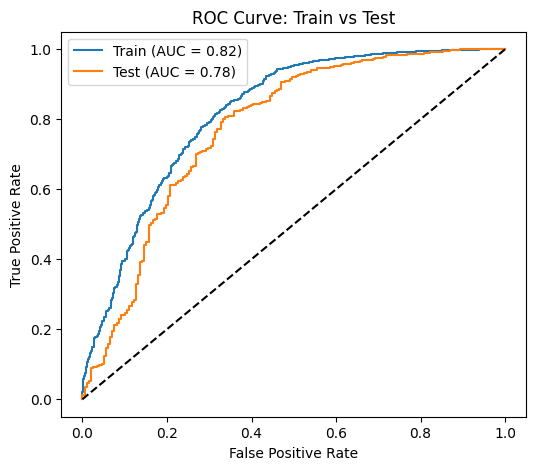

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_overfit(y_train, y_train_prob, y_test, y_test_prob):
    plt.figure(figsize=(6, 5))
    
    for y_true, y_prob, label in [(y_train, y_train_prob, 'Train'), (y_test, y_test_prob, 'Test')]:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--') 
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve: Train vs Test')
    plt.legend()
    plt.show()

plot_roc_overfit(y_train, y_train_prob, y_test, y_test_prob)

**Conclusion: No overfit, since the difference between AUC train and AUC test is not significant**